Exercício 1
P(X > 15,2 kg) = 0.022750
Em porcentagem: 2.2750%
        count         mean         std     min     25%     50%     75%     max
sex                                                                           
Female  165.0  3862.272727  666.172050  2700.0  3350.0  3650.0  4550.0  5200.0
Male    168.0  4545.684524  787.628884  3250.0  3900.0  4300.0  5312.5  6300.0


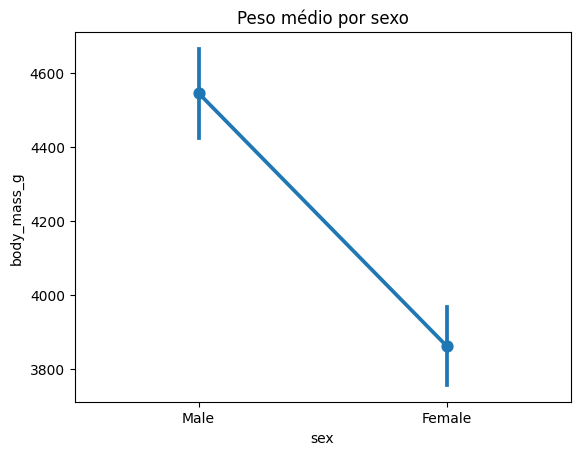

Exercício 1 — Teste T (todos os pinguins)
Média machos:         4545.68 g
Média fêmeas:         3862.27 g
Estatística t:        8.5417
Valor crítico (±):    1.9672
p-value:              4.90e-16
Graus de liberdade:   331

Rejeita H0 — há diferença significativa de peso entre machos e fêmeas.


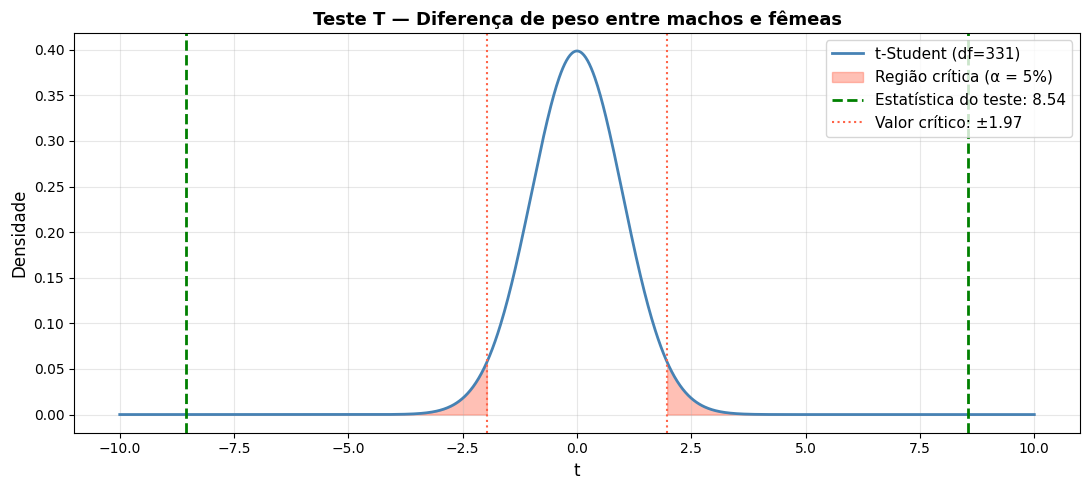


Exercício 3 — Teste T por espécie
  Espécie  n machos  n fêmeas  Média machos  Média fêmeas  Estatística t  p-value  Conclusão
   Adelie        73        73        4043.5        3368.8        13.1263 0.000000 Rejeita H0
Chinstrap        34        34        3939.0        3527.2         5.2077 0.000002 Rejeita H0
   Gentoo        61        58        5484.8        4679.7        14.7217 0.000000 Rejeita H0

  Em todas as 3 espécies o p-value << 0,05:
   Há evidência significativa de diferença de peso entre machos e fêmeas.


In [ ]:
#importando bibliotecas
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


# Exercício 1

# Máquina embala pacotes com distribuição Normal: média=15kg, dp=0,1kg
# P(X > 15.2) = ?

prob_maior_152 = 1 - stats.norm.cdf(15.2, loc=15, scale=0.1)

print("=" * 55)
print("Exercício 1")
print("=" * 55)
print(f"P(X > 15,2 kg) = {prob_maior_152:.6f}")
print(f"Em porcentagem: {prob_maior_152 * 100:.4f}%")

# Probabilidade - Tarefa M33 | Teste T


import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Carrega o dataset
pg = sns.load_dataset('penguins')

# Visão geral dos dados
print(pg.groupby('sex')['body_mass_g'].describe())
sns.pointplot(data=pg, x='sex', y='body_mass_g')
plt.title('Peso médio por sexo')
plt.show()


# Exercício 1 — Teste T: machos vs fêmeas (toda a população)

# H0: não há diferença de peso entre machos e fêmeas
# H1: há diferença de peso entre machos e fêmeas
# Significância: α = 5%

male   = pg[pg['sex'] == 'Male']['body_mass_g'].dropna()
female = pg[pg['sex'] == 'Female']['body_mass_g'].dropna()

t_stat, p_value = stats.ttest_ind(male, female)
df_test = len(male) + len(female) - 2
t_crit  = stats.t.ppf(0.975, df=df_test)   # bicaudal → 1 - α/2

print("=" * 55)
print("Exercício 1 — Teste T (todos os pinguins)")
print("=" * 55)
print(f"Média machos:         {male.mean():.2f} g")
print(f"Média fêmeas:         {female.mean():.2f} g")
print(f"Estatística t:        {t_stat:.4f}")
print(f"Valor crítico (±):    {t_crit:.4f}")
print(f"p-value:              {p_value:.2e}")
print(f"Graus de liberdade:   {df_test}")
print()
if p_value < 0.05:
    print("Rejeita H0 — há diferença significativa de peso entre machos e fêmeas.")
else:
    print("Não rejeita H0 — sem evidência de diferença significativa.")


# Exercício 2 — Representação gráfica do teste


x   = np.linspace(-10, 10, 1000)
pdf = stats.t.pdf(x, df=df_test)

fig, ax = plt.subplots(figsize=(11, 5))

# Curva da distribuição t
ax.plot(x, pdf, color='steelblue', linewidth=2, label=f't-Student (df={df_test})')

# Região crítica (em vermelho)
ax.fill_between(x, pdf, where=(x >=  t_crit), color='tomato', alpha=0.4,
                label=f'Região crítica (α = 5%)')
ax.fill_between(x, pdf, where=(x <= -t_crit), color='tomato', alpha=0.4)

# Estatística do teste (em verde)
ax.axvline( t_stat, color='green', linestyle='--', linewidth=2,
            label=f'Estatística do teste: {t_stat:.2f}')
ax.axvline(-t_stat, color='green', linestyle='--', linewidth=2)

# Valores críticos
ax.axvline( t_crit, color='tomato', linestyle=':', linewidth=1.5,
            label=f'Valor crítico: ±{t_crit:.2f}')
ax.axvline(-t_crit, color='tomato', linestyle=':', linewidth=1.5)

ax.set_title('Teste T — Diferença de peso entre machos e fêmeas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Exercício 3 — Teste T por espécie


print("\n" + "=" * 55)
print("Exercício 3 — Teste T por espécie")
print("=" * 55)

resultados = []

for especie in pg['species'].unique():
    sub = pg[pg['species'] == especie]
    m   = sub[sub['sex'] == 'Male']['body_mass_g'].dropna()
    f   = sub[sub['sex'] == 'Female']['body_mass_g'].dropna()

    t, p = stats.ttest_ind(m, f)
    conclusao = "Rejeita H0" if p < 0.05 else "Não rejeita H0"

    resultados.append({
        'Espécie':       especie,
        'n machos':      len(m),
        'n fêmeas':      len(f),
        'Média machos':  round(m.mean(), 1),
        'Média fêmeas':  round(f.mean(), 1),
        'Estatística t': round(t, 4),
        'p-value':       round(p, 6),
        'Conclusão':     conclusao
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

print("\n  Em todas as 3 espécies o p-value << 0,05:")
print("   Há evidência significativa de diferença de peso entre machos e fêmeas.")

**Conclusão e Insights**

Os resultados mostraram que a probabilidade de um pacote ultrapassar 15,2 kg é de apenas 2,28%, indicando que a maioria dos pacotes permanece próxima ao peso esperado de 15 kg e que ocorrências acima desse limite são relativamente raras.

Na análise dos pinguins, o teste T revelou uma diferença estatisticamente significativa no peso corporal entre machos e fêmeas. Considerando todas as espécies em conjunto, os machos apresentaram peso médio de 4545,68 g, enquanto as fêmeas tiveram média de 3862,27 g, uma diferença de aproximadamente 683 g.

Quando a análise foi realizada por espécie (Adelie, Chinstrap e Gentoo), o mesmo padrão foi observado: em todos os casos, os machos apresentaram peso médio significativamente superior ao das fêmeas.

Esses resultados sugerem que o dimorfismo sexual no peso corporal é uma característica marcante das espécies estudadas, evidenciando diferenças biológicas consistentes entre machos e fêmeas. Além de confirmar a importância dos testes estatísticos para a tomada de decisões baseada em dados, o estudo demonstra como a análise quantitativa pode revelar padrões relevantes sobre características e comportamentos das populações analisadas.